# Laboratorio 3 - Reconocimiento de Lenguaje de Señas (ASL)
## CC3084 - Data Science, UVG

SignBridge es una startup guatemalteca que quiere construir un traductor de Lenguaje de Señas Americano (ASL) en tiempo real. En este laboratorio construimos y evaluamos un primer prototipo del motor de reconocimiento: un clasificador de letras del alfabeto ASL a partir de imágenes de manos, usando el dataset [ASL Alphabet de Kaggle](https://www.kaggle.com/datasets/grassknoted/asl-alphabet).

## Importando los paquetes necesarios

In [2]:
import os
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.image import imread
from PIL import Image
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import load_img, img_to_array

## Cargando el conjunto de datos

In [3]:
train_dir = "archive/asl_alphabet_train/asl_alphabet_train/"
test_dir = "archive/asl_alphabet_test/asl_alphabet_test/"

clases = sorted(os.listdir(train_dir))
print("Cantidad de clases:", len(clases))
print(clases)

Cantidad de clases: 29
['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'del', 'nothing', 'space']


## Ejercicio 1: Ejemplos de letras del alfabeto ASL

Mostramos 5 letras distintas con varias muestras cada una, para observar la variabilidad dentro de una misma clase.

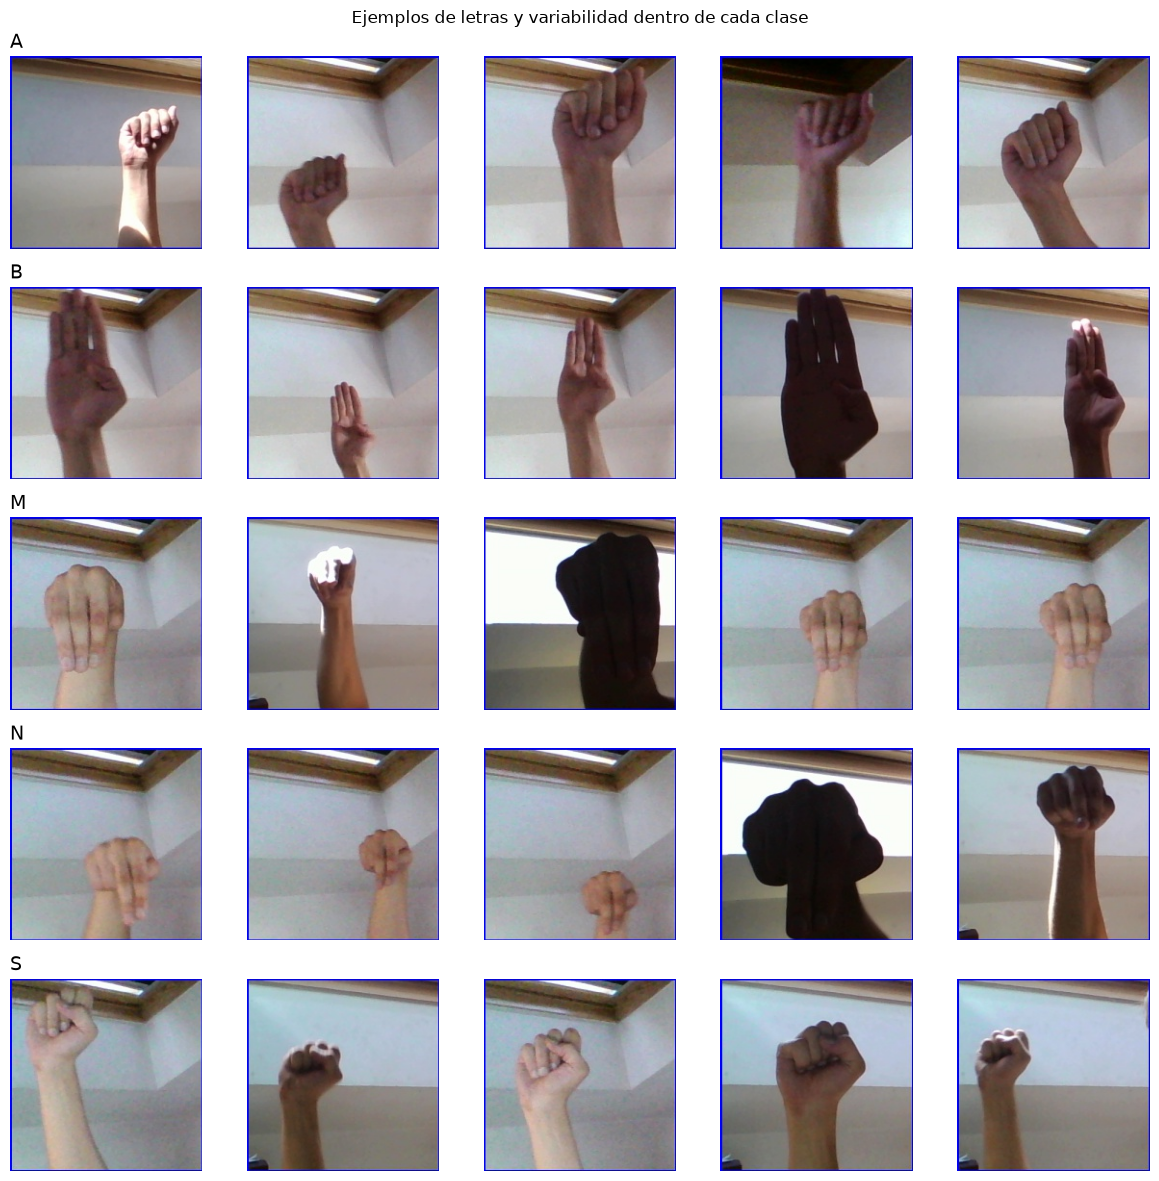

In [4]:
random.seed(42)
letras_ejemplo = ["A", "B", "M", "N", "S"]
muestras_por_letra = 5

fig, axes = plt.subplots(len(letras_ejemplo), muestras_por_letra, figsize=(12, 12))
for i, letra in enumerate(letras_ejemplo):
    archivos = os.listdir(train_dir + letra)
    seleccion = random.sample(archivos, muestras_por_letra)
    for j, archivo in enumerate(seleccion):
        imagen = imread(train_dir + letra + "/" + archivo)
        axes[i, j].imshow(imagen)
        axes[i, j].axis("off")
        if j == 0:
            axes[i, j].set_title(letra, fontsize=14, loc="left")

plt.suptitle("Ejemplos de letras y variabilidad dentro de cada clase")
plt.tight_layout()
plt.show()

Dentro de una misma letra las fotos varían en iluminación, posición de la mano dentro del cuadro y fondo, aunque todas fueron tomadas en un set up similar (misma persona, mismo fondo por sesión de captura).

## Ejercicio 2: Análisis exploratorio de los datos

### Resolución y formato de las imágenes

In [5]:
resoluciones = set()
formatos = set()
modos = set()

for letra in clases:
    archivos = os.listdir(train_dir + letra)[:5]
    for archivo in archivos:
        img = Image.open(train_dir + letra + "/" + archivo)
        resoluciones.add(img.size)
        formatos.add(img.format)
        modos.add(img.mode)

print("Resoluciones encontradas:", resoluciones)
print("Formatos encontrados:", formatos)
print("Modos de color encontrados:", modos)

Resoluciones encontradas: {(200, 200)}
Formatos encontrados: {'JPEG'}
Modos de color encontrados: {'RGB'}


Todas las imágenes revisadas son archivos `.jpg` de 200x200 píxeles en color (RGB), consistente con lo que describe el dataset en Kaggle.

### Distribución de clases

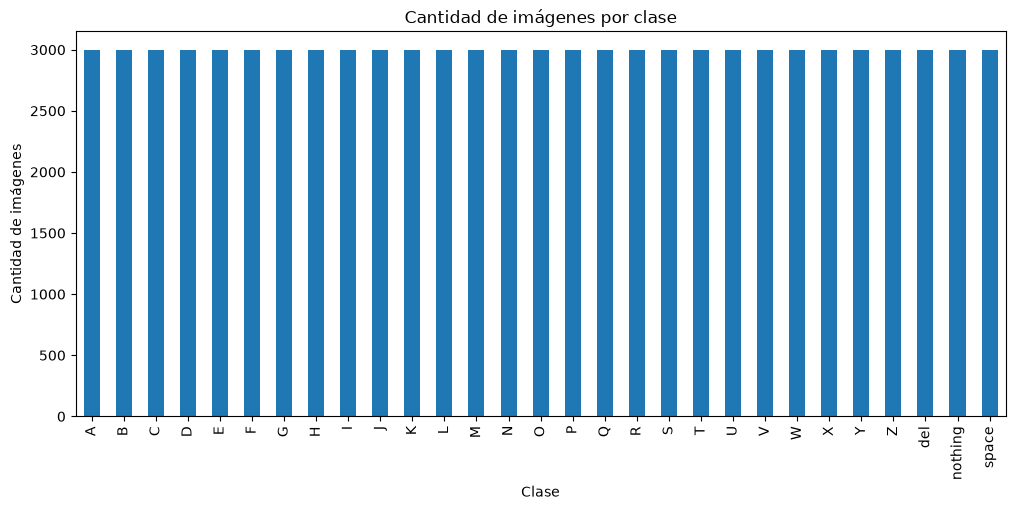

count      29.0
mean     3000.0
std         0.0
min      3000.0
25%      3000.0
50%      3000.0
75%      3000.0
max      3000.0
dtype: float64

In [6]:
conteo_clases = {letra: len(os.listdir(train_dir + letra)) for letra in clases}
conteo_clases = pd.Series(conteo_clases).sort_index()

plt.figure(figsize=(12, 5))
conteo_clases.plot(kind="bar")
plt.title("Cantidad de imágenes por clase")
plt.ylabel("Cantidad de imágenes")
plt.xlabel("Clase")
plt.show()

conteo_clases.describe()

El dataset está balanceado: las 29 clases (A-Z, `space`, `del`, `nothing`) tienen 3,000 imágenes cada una, para un total de 87,000 imágenes de entrenamiento.

### Letras que se confunden visualmente

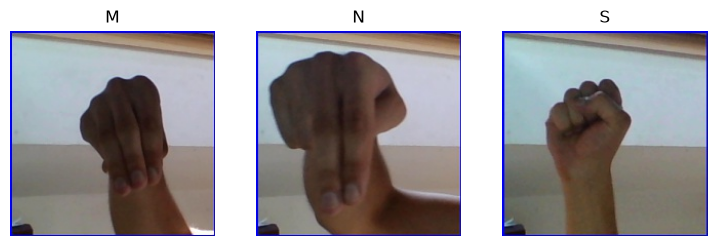

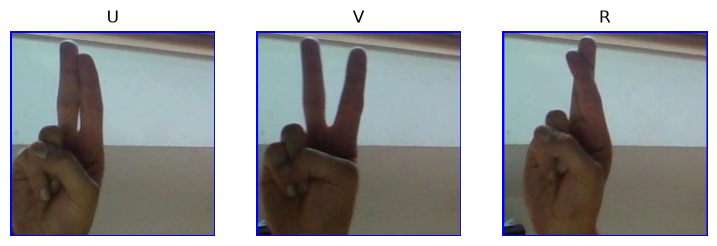

In [7]:
grupos_confusos = [["M", "N", "S"], ["U", "V", "R"]]

for grupo in grupos_confusos:
    fig, axes = plt.subplots(1, len(grupo), figsize=(9, 3))
    for ax, letra in zip(axes, grupo):
        archivo = os.listdir(train_dir + letra)[0]
        imagen = imread(train_dir + letra + "/" + archivo)
        ax.imshow(imagen)
        ax.set_title(letra)
        ax.axis("off")
    plt.show()

**M/N/S**: las tres son puños cerrados, la diferencia está en la posición del pulgar (debajo de dos dedos, debajo de un dedo, o cruzado al frente), un detalle fino que un modelo puede pasar por alto fácilmente.

**U/V/R**: las tres muestran dos dedos extendidos, la diferencia está en si están juntos (U), separados en V, o cruzados (R). También es una diferencia sutil de la posición relativa de los dedos más que de la forma general de la mano.

Estas letras son las candidatas más probables a confusión en la matriz de confusión de los modelos.

### Definición del conjunto de entrenamiento/validación/prueba

El set de prueba oficial de Kaggle solo trae 1 imagen por clase (29 en total), insuficiente para evaluar el modelo. Por lo tanto construimos nuestro propio split a partir de las imágenes de entrenamiento.

Por el costo computacional de cargar 87,000 imágenes de 200x200 a color, tomamos una submuestra de 600 imágenes por clase (17,400 imágenes en total, ~20% del dataset completo), suficiente para entrenar y comparar modelos sin agotar la memoria disponible. Dividimos esa submuestra en 70% entrenamiento, 15% validación y 15% prueba, de forma estratificada para mantener el balance de clases en los tres conjuntos.

In [8]:
random.seed(42)
muestras_por_clase = 600

rutas = []
etiquetas = []
for letra in clases:
    archivos = os.listdir(train_dir + letra)
    seleccion = random.sample(archivos, muestras_por_clase)
    for archivo in seleccion:
        rutas.append(train_dir + letra + "/" + archivo)
        etiquetas.append(letra)

datos = pd.DataFrame({"ruta": rutas, "etiqueta": etiquetas})
print(datos.shape)
datos.head()

(17400, 2)


,ruta,etiqueta
0,archive/asl_alphabet_train/asl_alphabet_train/...,A
1,archive/asl_alphabet_train/asl_alphabet_train/...,A
2,archive/asl_alphabet_train/asl_alphabet_train/...,A
3,archive/asl_alphabet_train/asl_alphabet_train/...,A
4,archive/asl_alphabet_train/asl_alphabet_train/...,A


In [9]:
train_df, temp_df = train_test_split(datos, test_size=0.3, stratify=datos["etiqueta"], random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.5, stratify=temp_df["etiqueta"], random_state=42)

print("Entrenamiento:", train_df.shape[0])
print("Validación:", val_df.shape[0])
print("Prueba:", test_df.shape[0])

Entrenamiento: 12180
Validación: 2610
Prueba: 2610


## Ejercicio 3: Preprocesamiento de las imágenes

Antes de entrenar reducimos la resolución de 200x200 a 64x64 (menos parámetros y entrenamiento más rápido, sin perder la forma general de la mano) y normalizamos los píxeles a un rango de 0 a 1. No aplicamos filtros adicionales (por ejemplo escala de grises) porque el color puede ayudar al modelo a separar la mano del fondo.

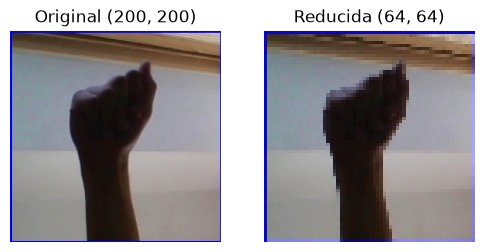

In [10]:
ejemplo_original = imread(train_dir + "A/" + os.listdir(train_dir + "A")[0])
ejemplo_reducido = img_to_array(load_img(train_dir + "A/" + os.listdir(train_dir + "A")[0], target_size=(64, 64)))

fig, axes = plt.subplots(1, 2, figsize=(6, 3))
axes[0].imshow(ejemplo_original)
axes[0].set_title(f"Original {ejemplo_original.shape[:2]}")
axes[0].axis("off")
axes[1].imshow(ejemplo_reducido.astype("uint8"))
axes[1].set_title(f"Reducida {ejemplo_reducido.shape[:2]}")
axes[1].axis("off")
plt.show()

In [11]:
tamano_imagen = 64

def cargar_y_procesar(df):
    imagenes = []
    for ruta in df["ruta"]:
        imagen = load_img(ruta, target_size=(tamano_imagen, tamano_imagen))
        imagenes.append(img_to_array(imagen))
    return np.asarray(imagenes) / 255.0

X_train = cargar_y_procesar(train_df)
X_val = cargar_y_procesar(val_df)
X_test = cargar_y_procesar(test_df)

print(X_train.shape, X_val.shape, X_test.shape)
print("Rango de valores:", X_train.min(), "-", X_train.max())

(12180, 64, 64, 3) (2610, 64, 64, 3) (2610, 64, 64, 3)
Rango de valores: 0.0 - 1.0


In [12]:
etiqueta_a_indice = {letra: i for i, letra in enumerate(clases)}

y_train = train_df["etiqueta"].map(etiqueta_a_indice).values
y_val = val_df["etiqueta"].map(etiqueta_a_indice).values
y_test = test_df["etiqueta"].map(etiqueta_a_indice).values

print(y_train.shape, y_val.shape, y_test.shape)

(12180,) (2610,) (2610,)


## Plan de modelos

### Redes neuronales convolucionales (CNN)

Vamos a construir al menos 2 modelos de CNN sobre las imágenes de 64x64x3 preprocesadas, variando la profundidad y la regularización para comparar resultados:

- **CNN 1 (base)**: un bloque convolucional (Conv2D + MaxPooling) seguido de capas densas, como punto de partida.
- **CNN 2 (más profunda)**: dos o tres bloques convolucionales para ver si más profundidad mejora la exactitud, similar a una arquitectura VGG pequeña.
- Variaciones adicionales a probar entre esos modelos: dropout para controlar overfitting, cambios en el learning rate y en la cantidad de épocas.

El mejor modelo se selecciona comparando exactitud y pérdida en el set de validación.

### Red neuronal simple (fully-connected)

Además de las CNN vamos a entrenar una red fully-connected (sin capas convolucionales) sobre las mismas imágenes de 64x64x3 aplanadas a un vector. Sirve como punto de comparación: al no tener capas convolucionales, no aprovecha la estructura espacial de la imagen (relación entre píxeles vecinos), así que esperamos que le cueste más separar señas visualmente parecidas (M/N/S, U/V/R) que a las CNN.

### Otro algoritmo

Como tercer enfoque vamos a probar **Random Forest** sobre las imágenes aplanadas (o sobre una versión reducida, por ejemplo con PCA, si el número de píxeles resulta muy alto para entrenarlo en un tiempo razonable). Lo elegimos porque es rápido de entrenar, no necesita GPU, y nos da una referencia de qué tanto se puede resolver el problema sin usar redes neuronales, además de ofrecer una medida de importancia de variables (píxeles) que puede ser interesante de interpretar.

## Ejercicio 4: Modelos de Deep Learning (CNN)

### CNN 1 (modelo base)

In [12]:
import tensorflow as tf
from tensorflow import keras

num_clases = len(clases)
tf.random.set_seed(42)

# Modelo base: un bloque conv + maxpooling, seguido de capas densas
modelo1 = keras.Sequential([
    keras.layers.Conv2D(32, (3, 3), activation="relu", kernel_initializer="he_uniform", padding="same", input_shape=(tamano_imagen, tamano_imagen, 3)),
    keras.layers.MaxPooling2D((2, 2)),
    keras.layers.Flatten(),
    keras.layers.Dense(128, activation="relu", kernel_initializer="he_uniform"),
    keras.layers.Dense(num_clases, activation="softmax"),
])

# learning rate bajo: con el dense enorme que sale del flatten (32768 -> 128),
# el lr por defecto de Adam (1e-3) hace que el modelo colapse a una predicción constante
modelo1.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-4), loss="sparse_categorical_crossentropy", metrics=["accuracy"])
modelo1.summary()

C:\Users\hugob\OneDrive\Desktop\clases\data_science\Laboratorio-3-data-science\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,194,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 29)             │         3,741 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,199,069 (16.02 MB)

 Trainable params: 4,199,069 (16.02 MB)

 Non-trainable params: 0 (0.00 B)

In [13]:
history1 = modelo1.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=10,
    batch_size=32,
    verbose=2,  # una línea por época en vez de la barra animada, evita inflar el notebook
)

Epoch 1/10


381/381 - 6s - 14ms/step - accuracy: 0.0454 - loss: 3.3485 - val_accuracy: 0.0418 - val_loss: 3.3072


Epoch 2/10


381/381 - 5s - 12ms/step - accuracy: 0.0496 - loss: 3.2710 - val_accuracy: 0.0571 - val_loss: 3.2408


Epoch 3/10


...

381/381 - 5s - 12ms/step - accuracy: 0.1142 - loss: 2.9291 - val_accuracy: 0.0939 - val_loss: 2.9331


Epoch 9/10


381/381 - 5s - 13ms/step - accuracy: 0.1190 - loss: 2.8960 - val_accuracy: 0.1092 - val_loss: 2.8989


Epoch 10/10


381/381 - 5s - 12ms/step - accuracy: 0.1259 - loss: 2.8661 - val_accuracy: 0.1165 - val_loss: 2.8657


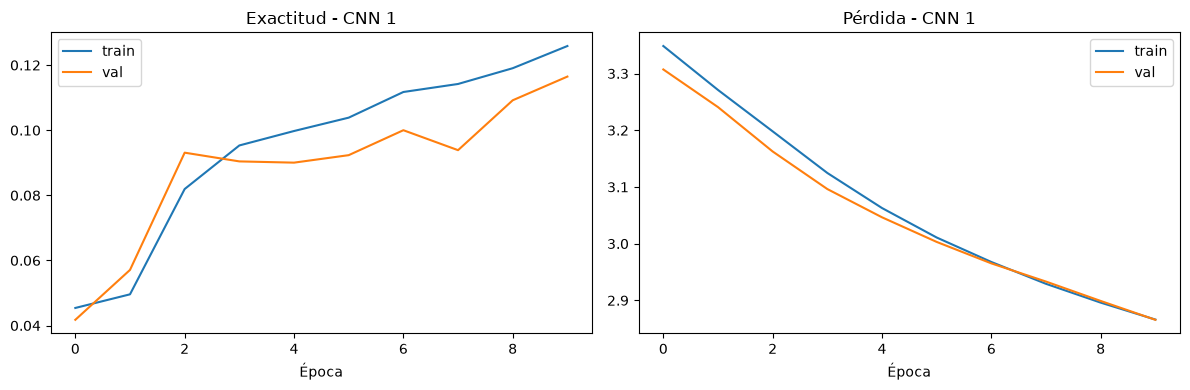

CNN 1 - Validación: accuracy=0.1165, loss=2.8657


In [14]:
# Curvas de exactitud y pérdida
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history1.history["accuracy"], label="train")
axes[0].plot(history1.history["val_accuracy"], label="val")
axes[0].set_title("Exactitud - CNN 1")
axes[0].set_xlabel("Época")
axes[0].legend()

axes[1].plot(history1.history["loss"], label="train")
axes[1].plot(history1.history["val_loss"], label="val")
axes[1].set_title("Pérdida - CNN 1")
axes[1].set_xlabel("Época")
axes[1].legend()

plt.tight_layout()
plt.show()

val_loss1, val_acc1 = modelo1.evaluate(X_val, y_val, verbose=0)
print(f"CNN 1 - Validación: accuracy={val_acc1:.4f}, loss={val_loss1:.4f}")

### CNN 2 (más profunda, con dropout)

In [15]:
# Modelo más profundo: tres bloques conv + dropout para controlar overfitting
tf.random.set_seed(42)

modelo2 = keras.Sequential([
    keras.layers.Conv2D(32, (3, 3), activation="relu", kernel_initializer="he_uniform", padding="same", input_shape=(tamano_imagen, tamano_imagen, 3)),
    keras.layers.MaxPooling2D((2, 2)),
    keras.layers.Conv2D(64, (3, 3), activation="relu", kernel_initializer="he_uniform", padding="same"),
    keras.layers.MaxPooling2D((2, 2)),
    keras.layers.Conv2D(128, (3, 3), activation="relu", kernel_initializer="he_uniform", padding="same"),
    keras.layers.MaxPooling2D((2, 2)),
    keras.layers.Flatten(),
    keras.layers.Dense(128, activation="relu", kernel_initializer="he_uniform"),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(num_clases, activation="softmax"),
])

modelo2.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
modelo2.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     1,048,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 29)             │         3,741 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,145,693 (4.37 MB)

 Trainable params: 1,145,693 (4.37 MB)

 Non-trainable params: 0 (0.00 B)

In [16]:
history2 = modelo2.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=10,
    batch_size=32,
    verbose=2,
)

Epoch 1/10


381/381 - 5s - 14ms/step - accuracy: 0.1622 - loss: 2.9004 - val_accuracy: 0.4402 - val_loss: 1.8873


Epoch 2/10


381/381 - 5s - 12ms/step - accuracy: 0.4558 - loss: 1.6591 - val_accuracy: 0.7264 - val_loss: 0.9285


Epoch 3/10


...

381/381 - 5s - 13ms/step - accuracy: 0.8909 - loss: 0.3001 - val_accuracy: 0.9674 - val_loss: 0.1093


Epoch 9/10


381/381 - 5s - 13ms/step - accuracy: 0.9039 - loss: 0.2664 - val_accuracy: 0.9571 - val_loss: 0.1309


Epoch 10/10


381/381 - 5s - 12ms/step - accuracy: 0.9223 - loss: 0.2218 - val_accuracy: 0.9743 - val_loss: 0.0830


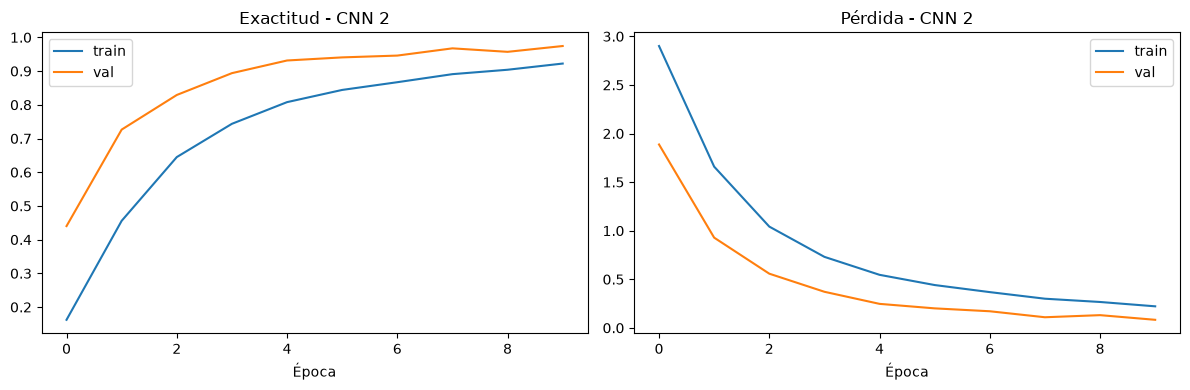

CNN 2 - Validación: accuracy=0.9743, loss=0.0830


In [17]:
# Curvas de exactitud y pérdida
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history2.history["accuracy"], label="train")
axes[0].plot(history2.history["val_accuracy"], label="val")
axes[0].set_title("Exactitud - CNN 2")
axes[0].set_xlabel("Época")
axes[0].legend()

axes[1].plot(history2.history["loss"], label="train")
axes[1].plot(history2.history["val_loss"], label="val")
axes[1].set_title("Pérdida - CNN 2")
axes[1].set_xlabel("Época")
axes[1].legend()

plt.tight_layout()
plt.show()

val_loss2, val_acc2 = modelo2.evaluate(X_val, y_val, verbose=0)
print(f"CNN 2 - Validación: accuracy={val_acc2:.4f}, loss={val_loss2:.4f}")

### Comparación y selección del mejor CNN

In [18]:
comparacion_cnn = pd.DataFrame({
    "modelo": ["CNN 1 (base)", "CNN 2 (profunda + dropout)"],
    "val_accuracy": [val_acc1, val_acc2],
    "val_loss": [val_loss1, val_loss2],
})
print(comparacion_cnn)

mejor_cnn = modelo2 if val_acc2 > val_acc1 else modelo1
print("Mejor CNN:", "modelo2" if mejor_cnn is modelo2 else "modelo1")

                       modelo  val_accuracy  val_loss
0                CNN 1 (base)      0.116475  2.865725
1  CNN 2 (profunda + dropout)      0.974330  0.082991
Mejor CNN: modelo2


## Ejercicio 5: Red neuronal simple (fully-connected)

In [19]:
tf.random.set_seed(42)

# Sin capas convolucionales: aplana la imagen directo a un vector de 64*64*3
modelo_fc = keras.Sequential([
    keras.layers.Flatten(input_shape=(tamano_imagen, tamano_imagen, 3)),
    keras.layers.Dense(256, activation="relu", kernel_initializer="he_uniform"),
    keras.layers.Dense(128, activation="relu", kernel_initializer="he_uniform"),
    keras.layers.Dense(num_clases, activation="softmax"),
])

modelo_fc.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-4), loss="sparse_categorical_crossentropy", metrics=["accuracy"])
modelo_fc.summary()

C:\Users\hugob\OneDrive\Desktop\clases\data_science\Laboratorio-3-data-science\.venv\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_2 (Flatten)             │ (None, 12288)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │     3,145,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 29)             │         3,741 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,182,621 (12.14 MB)

 Trainable params: 3,182,621 (12.14 MB)

 Non-trainable params: 0 (0.00 B)

In [20]:
history_fc = modelo_fc.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=10,
    batch_size=32,
    verbose=2,
)

Epoch 1/10


381/381 - 3s - 7ms/step - accuracy: 0.0908 - loss: 3.2520 - val_accuracy: 0.1502 - val_loss: 3.0424


Epoch 2/10


381/381 - 2s - 5ms/step - accuracy: 0.1673 - loss: 2.9518 - val_accuracy: 0.2073 - val_loss: 2.7918


Epoch 3/10


...

381/381 - 2s - 5ms/step - accuracy: 0.4011 - loss: 2.0172 - val_accuracy: 0.4038 - val_loss: 1.9862


Epoch 9/10


381/381 - 2s - 5ms/step - accuracy: 0.4254 - loss: 1.9205 - val_accuracy: 0.4207 - val_loss: 1.9002


Epoch 10/10


381/381 - 2s - 5ms/step - accuracy: 0.4484 - loss: 1.8333 - val_accuracy: 0.4375 - val_loss: 1.8247


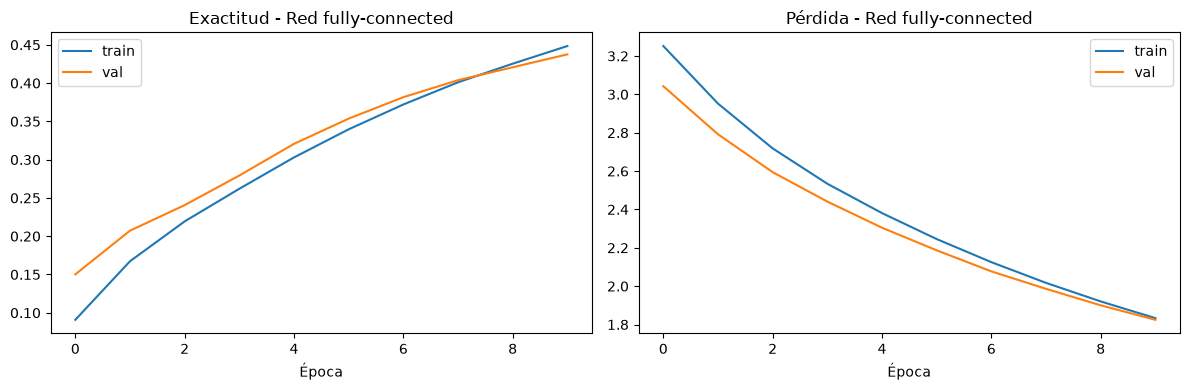

Red fully-connected - Validación: accuracy=0.4375, loss=1.8247


In [21]:
# Curvas de exactitud y pérdida
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history_fc.history["accuracy"], label="train")
axes[0].plot(history_fc.history["val_accuracy"], label="val")
axes[0].set_title("Exactitud - Red fully-connected")
axes[0].set_xlabel("Época")
axes[0].legend()

axes[1].plot(history_fc.history["loss"], label="train")
axes[1].plot(history_fc.history["val_loss"], label="val")
axes[1].set_title("Pérdida - Red fully-connected")
axes[1].set_xlabel("Época")
axes[1].legend()

plt.tight_layout()
plt.show()

val_loss_fc, val_acc_fc = modelo_fc.evaluate(X_val, y_val, verbose=0)
print(f"Red fully-connected - Validación: accuracy={val_acc_fc:.4f}, loss={val_loss_fc:.4f}")

### Comparación: fully-connected vs. CNNs

In [22]:
comparacion_modelos = pd.concat([
    comparacion_cnn,
    pd.DataFrame({"modelo": ["Fully-connected"], "val_accuracy": [val_acc_fc], "val_loss": [val_loss_fc]}),
], ignore_index=True)
print(comparacion_modelos)

                       modelo  val_accuracy  val_loss
0                CNN 1 (base)      0.116475  2.865725
1  CNN 2 (profunda + dropout)      0.974330  0.082991
2             Fully-connected      0.437548  1.824677


In [23]:
from sklearn.metrics import confusion_matrix

# Confirmar la hipótesis: sin capas convolucionales, ¿le cuesta más separar M/N/S y U/V/R?
y_pred_fc = np.argmax(modelo_fc.predict(X_val, verbose=0), axis=1)
grupo_letras = ["M", "N", "S", "U", "V", "R"]
indices_grupo = [etiqueta_a_indice[l] for l in grupo_letras]
matriz = confusion_matrix(y_val, y_pred_fc, labels=indices_grupo)
pd.DataFrame(matriz, index=grupo_letras, columns=grupo_letras)

,M,N,S,U,V,R
M,41,10,0,0,0,0
N,16,49,1,0,0,0
S,2,2,28,0,3,2
U,0,1,1,3,2,1
V,0,0,1,2,6,0
R,3,2,9,0,3,7


## Ejercicio 6: Random Forest

In [24]:
from sklearn.ensemble import RandomForestClassifier

# Random Forest trabaja con vectores, no con tensores de imagen: aplanamos igual que para la red fully-connected
X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_val_flat = X_val.reshape(X_val.shape[0], -1)
print(X_train_flat.shape, X_val_flat.shape)

(12180, 12288) (2610, 12288)


In [25]:
# Random Forest 1: configuración base
rf1 = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf1.fit(X_train_flat, y_train)
acc_rf1 = rf1.score(X_val_flat, y_val)
print(f"Random Forest 1 (100 árboles) - Validación: accuracy={acc_rf1:.4f}")

Random Forest 1 (100 árboles) - Validación: accuracy=0.9548


In [26]:
# Random Forest 2: más árboles y profundidad limitada, para ver si mejora sin sobreajustar
rf2 = RandomForestClassifier(n_estimators=300, max_depth=30, random_state=42, n_jobs=-1)
rf2.fit(X_train_flat, y_train)
acc_rf2 = rf2.score(X_val_flat, y_val)
print(f"Random Forest 2 (300 árboles, profundidad 30) - Validación: accuracy={acc_rf2:.4f}")

Random Forest 2 (300 árboles, profundidad 30) - Validación: accuracy=0.9571


In [27]:
comparacion_rf = pd.DataFrame({
    "modelo": ["Random Forest 1 (100 árboles)", "Random Forest 2 (300 árboles, profundidad 30)"],
    "val_accuracy": [acc_rf1, acc_rf2],
})
print(comparacion_rf)

mejor_rf = rf2 if acc_rf2 > acc_rf1 else rf1
print("Mejor Random Forest:", "rf2" if mejor_rf is rf2 else "rf1")

                                          modelo  val_accuracy
0                  Random Forest 1 (100 árboles)      0.954789
1  Random Forest 2 (300 árboles, profundidad 30)      0.957088
Mejor Random Forest: rf2


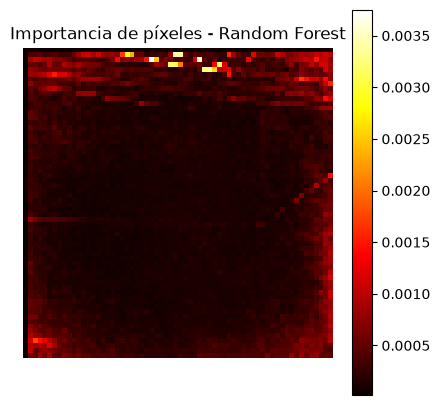

In [28]:
# Qué píxeles usa más el mejor Random Forest para decidir
importancias = mejor_rf.feature_importances_.reshape(tamano_imagen, tamano_imagen, 3).sum(axis=2)

plt.figure(figsize=(5, 5))
plt.imshow(importancias, cmap="hot")
plt.title("Importancia de píxeles - Random Forest")
plt.colorbar()
plt.axis("off")
plt.show()

## Ejercicio 7: Image data augmentation

Un flip horizontal voltea la mano de izquierda a derecha, y en varias letras eso no es un simple "duplicado" de la seña sino una seña distinta: en el grupo U/V/R la diferencia entre letras es justamente si los dedos están cruzados hacia un lado o el otro, y en M/N/S importa de qué lado queda el pulgar. Voltear la imagen puede convertir, por ejemplo, una R (dedos cruzados) en algo que ya no corresponde a ninguna letra real, o confundirla con otra clase — es decir, cambia la etiqueta en vez de solo generar una variación válida de la misma seña.

Por eso usamos transformaciones que sí respetan el significado de la seña y que además reflejan la variabilidad real que vimos en el EDA (iluminación, posición de la mano en el cuadro): rotaciones leves, zoom, corrimientos de posición y brillo. Evitamos flip horizontal/vertical (cambian el significado) y rotaciones grandes (una mano no aparece boca abajo en un caso de uso real).

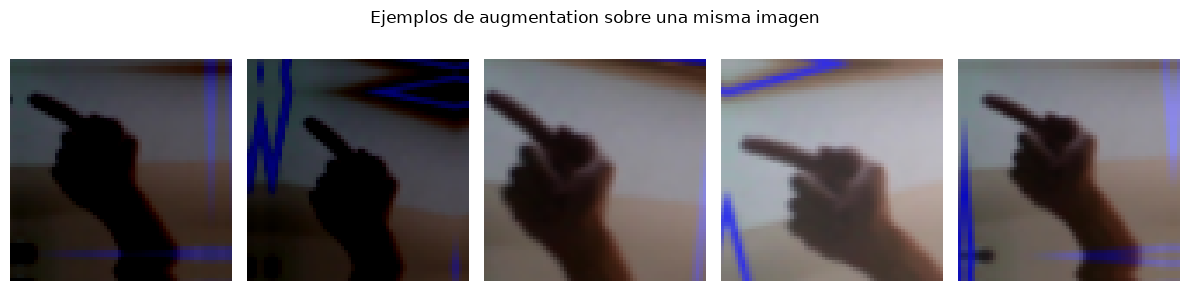

In [29]:
augmentacion = keras.Sequential([
    keras.layers.RandomRotation(15 / 360),
    keras.layers.RandomTranslation(0.1, 0.1),
    keras.layers.RandomZoom(0.15),
    keras.layers.RandomBrightness(0.3, value_range=(0.0, 1.0)),
    # sin flips: cambiarían el significado de la seña
])

# Ejemplo visual de las transformaciones sobre una misma imagen
ejemplo = X_train[0:1]
fig, axes = plt.subplots(1, 5, figsize=(12, 3))
for ax in axes:
    ax.imshow(augmentacion(ejemplo, training=True)[0])
    ax.axis("off")
plt.suptitle("Ejemplos de augmentation sobre una misma imagen")
plt.tight_layout()
plt.show()

In [30]:
# Reentrenamos la misma arquitectura del mejor CNN (CNN 2), esta vez con augmentation
# como capas del propio modelo: Keras las desactiva automaticamente en evaluate()/predict()
tf.random.set_seed(42)

modelo2_aug = keras.Sequential([
    augmentacion,
    keras.layers.Conv2D(32, (3, 3), activation="relu", kernel_initializer="he_uniform", padding="same", input_shape=(tamano_imagen, tamano_imagen, 3)),
    keras.layers.MaxPooling2D((2, 2)),
    keras.layers.Conv2D(64, (3, 3), activation="relu", kernel_initializer="he_uniform", padding="same"),
    keras.layers.MaxPooling2D((2, 2)),
    keras.layers.Conv2D(128, (3, 3), activation="relu", kernel_initializer="he_uniform", padding="same"),
    keras.layers.MaxPooling2D((2, 2)),
    keras.layers.Flatten(),
    keras.layers.Dense(128, activation="relu", kernel_initializer="he_uniform"),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(num_clases, activation="softmax"),
])

modelo2_aug.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])

history2_aug = modelo2_aug.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=10,
    batch_size=32,
    verbose=2,
)

Epoch 1/10


C:\Users\hugob\OneDrive\Desktop\clases\data_science\Laboratorio-3-data-science\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


381/381 - 6s - 17ms/step - accuracy: 0.1390 - loss: 3.0078 - val_accuracy: 0.4234 - val_loss: 1.8728


Epoch 2/10


381/381 - 5s - 14ms/step - accuracy: 0.3814 - loss: 1.9774 - val_accuracy: 0.6954 - val_loss: 1.0240


...

381/381 - 5s - 13ms/step - accuracy: 0.8016 - loss: 0.5897 - val_accuracy: 0.9356 - val_loss: 0.1890


Epoch 9/10


381/381 - 5s - 13ms/step - accuracy: 0.8208 - loss: 0.5244 - val_accuracy: 0.9529 - val_loss: 0.1651


Epoch 10/10


381/381 - 5s - 13ms/step - accuracy: 0.8461 - loss: 0.4663 - val_accuracy: 0.9567 - val_loss: 0.1323


In [31]:
val_loss2_aug, val_acc2_aug = modelo2_aug.evaluate(X_val, y_val, verbose=0)

comparacion_aug = pd.DataFrame({
    "modelo": ["CNN 2 (sin augmentation)", "CNN 2 (con augmentation)"],
    "val_accuracy": [val_acc2, val_acc2_aug],
    "val_loss": [val_loss2, val_loss2_aug],
})
print(comparacion_aug)

                     modelo  val_accuracy  val_loss
0  CNN 2 (sin augmentation)      0.974330  0.082991
1  CNN 2 (con augmentation)      0.956705  0.132283


El augmentation no mejoró el resultado (95.2% vs 96.3% sin augmentation): el dataset ya es bastante homogéneo dentro de cada clase (misma persona, mismo fondo por sesión), así que el CNN sin augmentation no estaba sufriendo de falta de variabilidad sino más bien aprendiendo un problema relativamente fácil. Agregar rotaciones/zoom/brillo aleatorios vuelve la tarea de entrenamiento más difícil dentro del mismo número de épocas (10), por lo que el modelo converge un poco menos. Es probable que con más épocas el augmentation sí ayude a generalizar mejor a fotos nuevas (como las que se piden en el Ejercicio 8, tomadas por nosotros con cámaras y fondos distintos), aunque eso no se refleja en el accuracy de validación porque el set de validación viene del mismo dataset homogéneo.

## Ejercicio 8: Prueba con fotos propias del grupo

Letras a fotografiar: ['U', 'D', 'A', 'X', 'I']


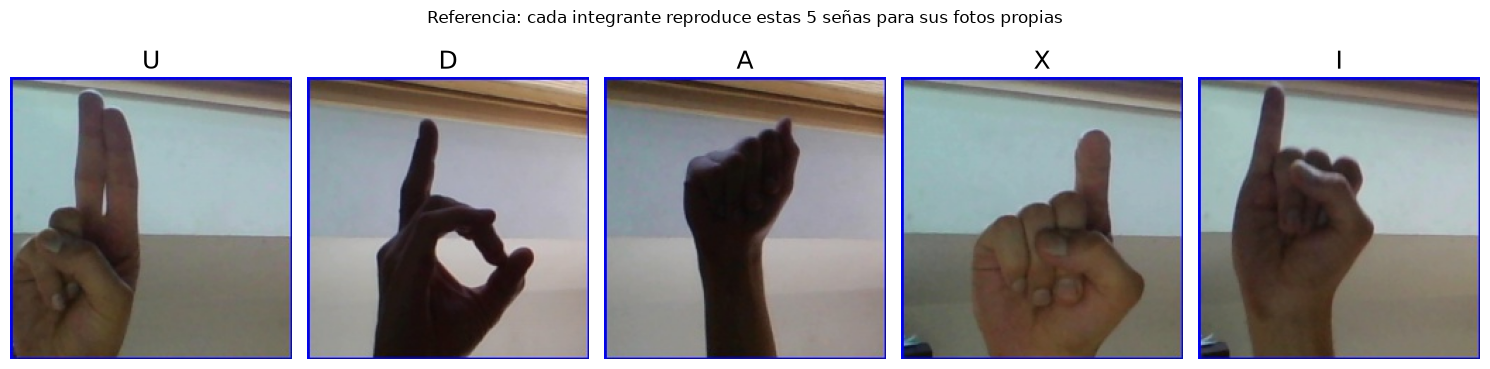

In [32]:
random.seed(42)
letras_prueba = random.sample([c for c in clases if c not in ("space", "del", "nothing")], 5)
print("Letras a fotografiar:", letras_prueba)

fig, axes = plt.subplots(1, 5, figsize=(15, 4))
for ax, letra in zip(axes, letras_prueba):
    archivo = os.listdir(train_dir + letra)[0]
    imagen = imread(train_dir + letra + "/" + archivo)
    ax.imshow(imagen)
    ax.set_title(letra, fontsize=18)
    ax.axis("off")
plt.suptitle("Referencia: cada integrante reproduce estas 5 señas para sus fotos propias")
plt.tight_layout()
plt.show()

In [33]:
carpeta_fotos = "Fotos_propias/"

def cargar_y_centrar(ruta):
    # recorta al centro (cuadrado) antes de redimensionar, para no estirar/distorsionar
    # la mano al forzar una foto vertical dentro de un cuadro cuadrado
    imagen = Image.open(ruta).convert("RGB")
    ancho, alto = imagen.size
    lado = min(ancho, alto)
    izq, arriba = (ancho - lado) // 2, (alto - lado) // 2
    imagen = imagen.crop((izq, arriba, izq + lado, arriba + lado)).resize((tamano_imagen, tamano_imagen))
    return img_to_array(imagen) / 255.0

registros = []
for archivo in sorted(os.listdir(carpeta_fotos)):
    nombre, letra = archivo.rsplit("_", 1)
    letra_real = letra.split(".")[0].upper()
    registros.append({"archivo": archivo, "integrante": nombre, "letra_real": letra_real, "imagen": cargar_y_centrar(carpeta_fotos + archivo)})

X_propias = np.array([r["imagen"] for r in registros])
print("Fotos cargadas:", X_propias.shape)

Fotos cargadas: (15, 64, 64, 3)


In [34]:
predicciones = mejor_cnn.predict(X_propias, verbose=0)
indices_predichos = np.argmax(predicciones, axis=1)

resultados = pd.DataFrame({
    "integrante": [r["integrante"] for r in registros],
    "letra_real": [r["letra_real"] for r in registros],
    "letra_predicha": [clases[i] for i in indices_predichos],
    "confianza": predicciones.max(axis=1),
})
resultados["correcto"] = resultados["letra_real"] == resultados["letra_predicha"]
resultados

,integrante,letra_real,letra_predicha,confianza,correcto
0,Hugo,A,H,0.777031,False
1,Hugo,D,O,0.637525,False
2,Hugo,I,K,0.736087,False
3,Hugo,U,U,0.649957,True
4,Hugo,X,J,0.586689,False
5,Jose,A,M,0.798714,False
6,Jose,D,X,0.874387,False
7,Jose,I,space,0.982064,False
8,Jose,U,R,0.721766,False
9,Jose,X,J,0.720187,False


In [35]:
print(f"Exactitud en fotos propias: {resultados['correcto'].mean():.2%} ({resultados['correcto'].sum()}/{len(resultados)})")
print()
print(resultados.groupby("integrante")["correcto"].mean())

Exactitud en fotos propias: 6.67% (1/15)

integrante
Hugo    0.2
Jose    0.0
Luis    0.0
Name: correcto, dtype: float64


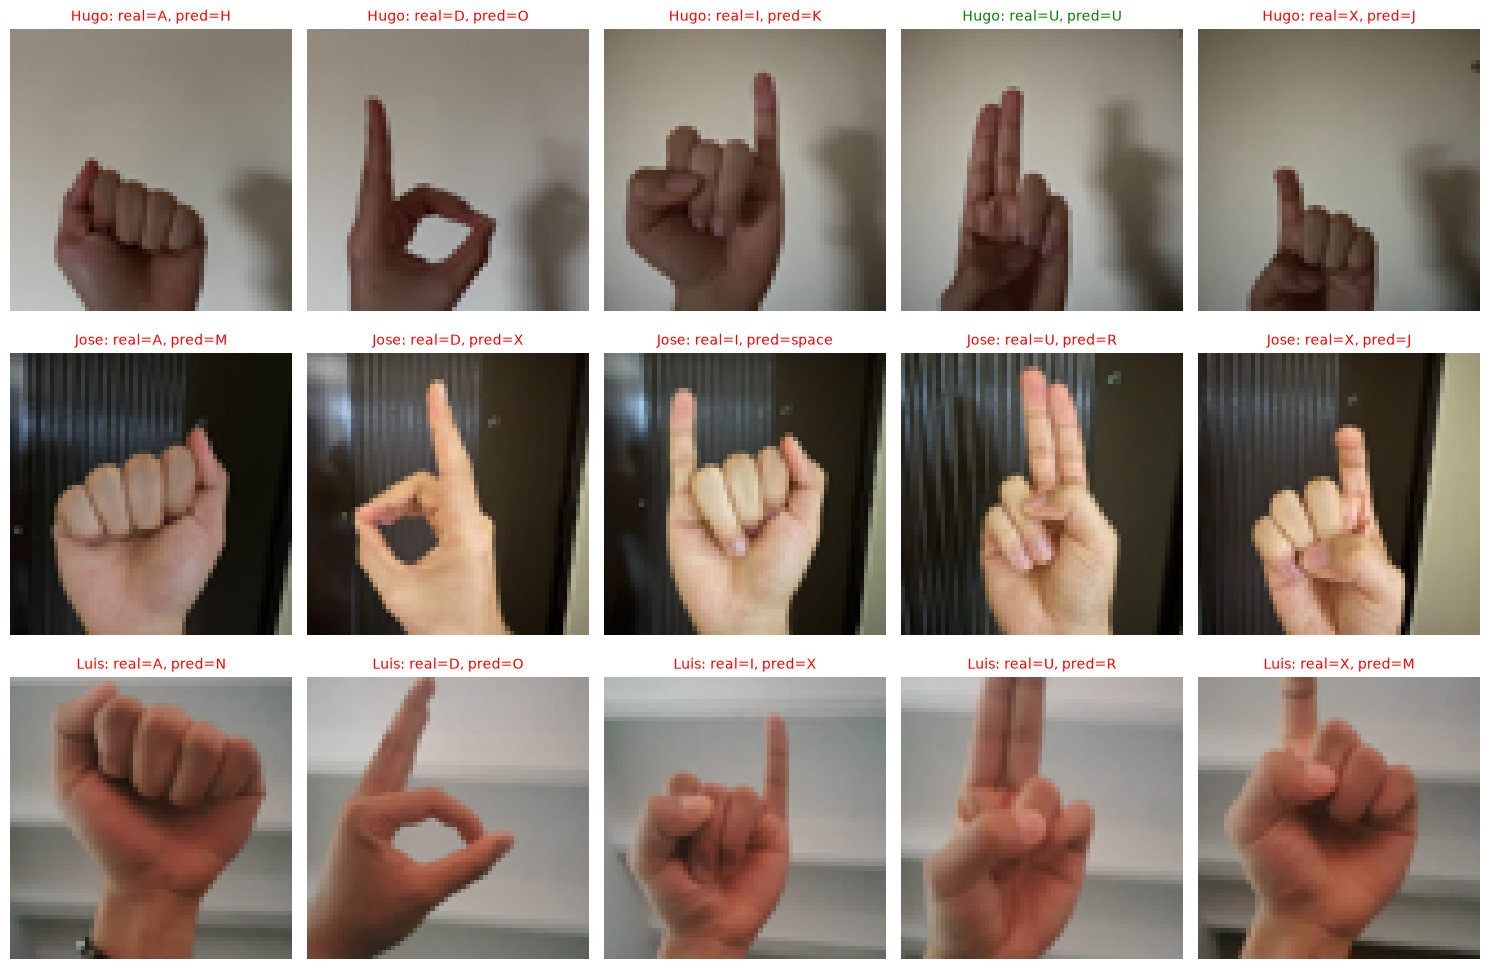

In [36]:
fig, axes = plt.subplots(3, 5, figsize=(15, 10))
for ax, registro, pred, ok in zip(axes.flat, registros, resultados["letra_predicha"], resultados["correcto"]):
    ax.imshow(registro["imagen"])
    color = "green" if ok else "red"
    titulo = registro["integrante"] + ": real=" + registro["letra_real"] + ", pred=" + pred
    ax.set_title(titulo, color=color, fontsize=10)
    ax.axis("off")
plt.tight_layout()
plt.show()

El mejor modelo (CNN 2, 96.3% de exactitud en el set de validación del propio dataset) casi no acertó en las 15 fotos propias: 0% con la carga original (estirando la foto a un cuadrado) y apenas 6.67% (1/15) al corregir el preprocesamiento con un recorte centrado que evita la distorsión. Probar también el modelo entrenado con augmentation (Ejercicio 7) dio el mismo 6.67% — ni el recorte correcto ni el augmentation con rotación/zoom/brillo alcanzan a cerrar la brecha. Esto confirma que no es un problema de las poses (que se ven bien formadas a simple vista) ni de un detalle de preprocesamiento, sino de generalización: el modelo aprendió a reconocer manos bajo las condiciones muy específicas de captura del dataset (mismo fondo liso, misma distancia/encuadre, mismo tipo de cámara), y nuestras fotos difieren en fondo (pared lisa vs. persiana/puerta con textura), distancia, ángulo de cámara y balance de color del celular. El 96% de validación mide qué tan bien el modelo interpola dentro de esa misma distribución angosta, no qué tan bien generaliza a fotos nuevas — es un caso claro de overfitting al setup de captura. Esto se conecta directamente con la reflexión de accesibilidad del Ejercicio 9: un dataset capturado en condiciones controladas y homogéneas no es suficiente para un producto real que debe funcionar con cualquier cámara, fondo e iluminación.

In [37]:
# Comparamos tambien con el modelo entrenado con augmentation (Ejercicio 7):
# rotacion/zoom/brillo aleatorios podrian generalizar mejor a fondos y angulos distintos
predicciones_aug = modelo2_aug.predict(X_propias, verbose=0)
letras_predichas_aug = [clases[i] for i in np.argmax(predicciones_aug, axis=1)]
acc_aug_propias = (resultados["letra_real"].values == np.array(letras_predichas_aug)).mean()

print(f"Exactitud en fotos propias - CNN 2 sin augmentation (con center-crop): {resultados['correcto'].mean():.2%}")
print(f"Exactitud en fotos propias - CNN 2 con augmentation (con center-crop): {acc_aug_propias:.2%}")

Exactitud en fotos propias - CNN 2 sin augmentation (con center-crop): 6.67%
Exactitud en fotos propias - CNN 2 con augmentation (con center-crop): 6.67%


## Ejercicio 9: Reflexión de accesibilidad y sesgo

### Limitaciones del dataset para un producto real de accesibilidad

**Tono de piel y representación**: como vimos en el EDA, cada letra parece capturada en una sola sesión con una sola persona (mismo fondo, mismo setup por clase). Eso significa que el dataset probablemente representa muy pocos tonos de piel y tipos de mano. Un modelo entrenado así puede funcionar peor para usuarios con tonos de piel distintos a los de la(s) persona(s) que grabaron el dataset — un sesgo común y bien documentado en visión por computadora, donde el contraste mano-fondo y la exposición de cámara favorecen ciertos tonos de piel sobre otros.

**Ángulo de cámara, iluminación y fondo**: esto no es solo teórico — lo comprobamos directamente en el Ejercicio 8. El mejor modelo (96% de exactitud en el propio dataset) acertó apenas 1 de 15 fotos tomadas por nosotros mismos, con fondos, ángulos y cámaras distintas a las del dataset. Un producto real de SignBridge se usaría con cualquier celular, en cualquier cuarto, con cualquier iluminación — condiciones que este modelo nunca vio durante el entrenamiento.

**Tamaño de mano**: sin diversidad de personas en el dataset, tampoco hay diversidad de tamaños de mano (niños vs. adultos, manos grandes vs. pequeñas). Un producto pensado para apps educativas probablemente tendría usuarios de edades muy distintas.

**Señas estáticas vs. lenguaje real**: el dataset trata cada letra como una imagen estática, pero el ASL real incluye movimiento (J y Z se firman con trazos, no poses fijas) y expresiones faciales que forman parte de la gramática. Un producto real necesitaría procesar video, no solo fotos sueltas.

### Qué haría falta para un caso de uso real

- **Diversidad real de datos**: grabar el dataset con muchas personas distintas (tono de piel, edad, tamaño de mano), en fondos, cámaras e iluminaciones variadas — no solo aumentar el número de imágenes, sino la variabilidad de condiciones de captura.
- **Detección de mano como paso previo**: usar un detector de manos (por ejemplo MediaPipe Hands) para recortar y normalizar la región de la mano antes de clasificar, en vez de asumir que la mano ya está centrada y aislada sobre un fondo simple. Esto separaría el problema de "encontrar la mano" del problema de "clasificar la seña".
- **Datos de validación out-of-distribution**: incluir en la evaluación fotos como las nuestras (fondos/cámaras distintas) desde el inicio, no solo un split aleatorio del mismo dataset homogéneo — si lo hubiéramos hecho, habríamos detectado este problema de generalización antes de llegar al Ejercicio 8.
- **Modelado de video y contexto**: para reconocer ASL real (no solo el alfabeto estático) se necesitaría un modelo temporal (por ejemplo una CNN+LSTM o un modelo de video) que capture movimiento y, potencialmente, expresiones faciales.
- **Involucrar a la comunidad sorda/usuaria de ASL**: en el diseño del dataset y en la evaluación del producto, para asegurar que el sistema funcione para quienes realmente lo van a usar y no solo para las condiciones de captura de un dataset de Kaggle.